This is a classification model that is trained to predict if an image has good quality for the lipids to even be segmented.

In [13]:
from fastai.vision.all import *
from utils import (
    generic_image_path,
    generic_image_path_processed,
    generic_segmentation_path,
    generic_segmentation_path_processed,
    paste_imgs,
)
np.int = np.int32 # Need to add this to make preset model work

In [45]:
# In order to not keep changing the folder names in the utils file. I organized the "data/" folder to be inside different resolution scenario folders.
# So revise the root path assigned when necessary.
root = Path("../test_lipid_classification")

# df = pd.read_csv("metadata.csv")
df = pd.read_csv("../test_lipid_classification/metadata_uvp6_lipid.csv")

image_path_processed = generic_image_path_processed(root)

def label_func(p:Path):
    return segmentation_path_processed(p.name)

df['image_file_processed'] = df.filename.apply(image_path_processed)

# print(df[1:5])

                    filename         label  \
1  20230813-135838-524_1.png  cant segment   
2  20230813-135841-002_1.png  cant segment   
3  20230813-135841-042_2.png  cant segment   
4  20230813-135842-242_1.png         lipid   

                                                           image_file_processed  
1  ..\test_lipid_classification\data\images_processed\20230813-135838-524_1.png  
2  ..\test_lipid_classification\data\images_processed\20230813-135841-002_1.png  
3  ..\test_lipid_classification\data\images_processed\20230813-135841-042_2.png  
4  ..\test_lipid_classification\data\images_processed\20230813-135842-242_1.png  


### Training

In [48]:
# Create a new data block that is a categoryblock instead of a maskblock
dls =  DataBlock(
    blocks=(ImageBlock,CategoryBlock),
    get_x = ColReader("image_file_processed"),
    get_y = ColReader("label"),

    # need to convert all images to the same size
    item_tfms=Resize(224, method=ResizeMethod.Pad, pad_mode='zeros'), # aparently 224x224 is optimal for resnet34

    # TODO Add a batch norm?
    
    splitter=RandomSplitter(valid_pct=0.8, seed=88)
    # splitter=ColSplitter("is_valid"),
).dataloaders(df, batch_size=8, drop_last=True)

Due to IPython and Windows limitation, python multiprocessing isn't available now.
So `number_workers` is changed to 0 to avoid getting stuck


C:\Users\patri\anaconda3\envs\loki-inference\lib\site-packages\fastai\data\transforms.py:220: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if is_categorical_dtype(col):


In [49]:
# Create learner with default loss functions and metrics
learn = cnn_learner(dls, resnet34, metrics=accuracy )

cbs = []
cbs.append(EarlyStoppingCallback(patience=5))
cbs.append(SaveModelCallback(fname="model_resnet34_lipidcateg")) 
cbs.append(GradientAccumulation(n_acc=8))


learn.fine_tune(40, cbs = cbs)

# # To identify the optimal learning rate if necessary:
# # learn.lr_find()


epoch,train_loss,valid_loss,accuracy,time
0,1.438614,0.769384,0.682432,01:39


Better model found at epoch 0 with valid_loss value: 0.76938396692276.


epoch,train_loss,valid_loss,accuracy,time
0,1.327040,0.865058,0.675676,01:36
1,1.089362,0.861996,0.628378,01:37
2,0.908816,0.951180,0.585135,01:37
3,0.796707,0.938939,0.616216,01:35
4,0.705853,0.934265,0.631081,01:36
5,0.645785,1.063740,0.613514,01:40
6,0.610094,1.299660,0.582432,01:38


Better model found at epoch 0 with valid_loss value: 0.8650583028793335.
Better model found at epoch 1 with valid_loss value: 0.8619958758354187.
No improvement since epoch 1: early stopping


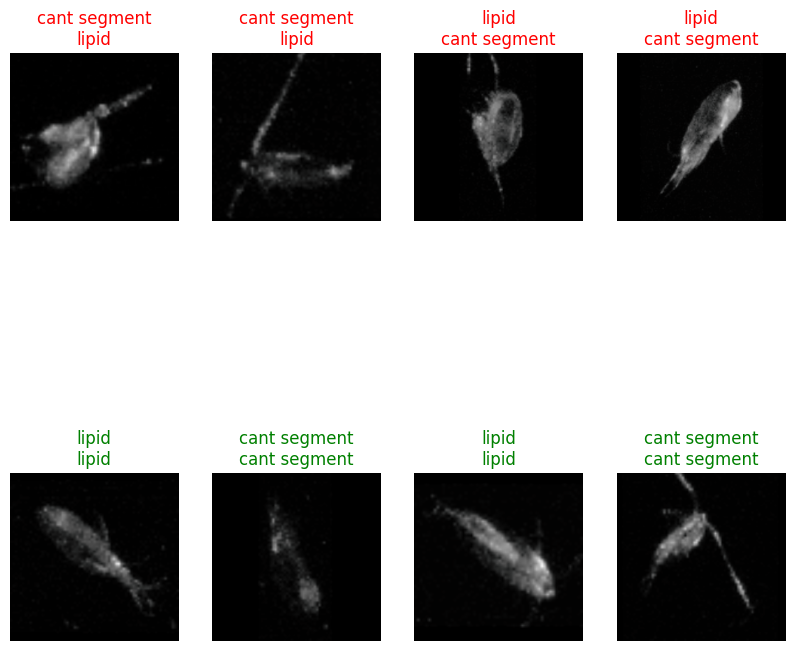

In [50]:
learn.summary()
# For exploring the model res") # Should this ults
learn.show_results(figsize =(10,10))

In [51]:
# Save load validate
learn.save("resnet34_lipid_classifier")  # Saves in 'models/resnet34_classifier.pth'

learn = cnn_learner(dls, resnet34, metrics=accuracy)  # Recreate the learner
learn.load("resnet34_lipid_classifier")  # Load saved model

valid_loss, valid_acc = learn.validate()
print(f"Validation Loss: {valid_loss:.4f}, Validation Accuracy: {valid_acc:.4f}")


Validation Loss: 0.8620, Validation Accuracy: 0.6284


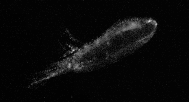

Predicted Class: lipid
Confidence Scores: TensorBase([0.1666, 0.8334])


In [61]:
# Test model with new data
img = PILImage.create("../uvp6_939_images/images_with_lipid/20211012-172206-798_1.png")  # Load an image
display(img)
pred, pred_idx, probs = learn.predict(img)

print(f"Predicted Class: {pred}")
print(f"Confidence Scores: {probs}")

In [ ]:
***** OLD SCRIPTS *****